# A first linear model: what explains the wait to be seen?

**Master in Healthcare Analytics · Session: Linear models I**
Dataset: ED tracking board, Riverbend Community Hospital (fictional), calendar year 2025.

Earlier sessions described the wait to see a provider one factor at a time: it rises with crowding, it jumps in the afternoon, it depends on acuity. A **linear model** puts several factors into one equation and estimates how much each contributes *while holding the others fixed*. This session builds the simplest version of that model, learns to read it, checks whether it is any good, and improves it in two steps that the diagnostics themselves suggest.

**Plan.**

1. The question, the response and three continuous predictors.
2. The model as an equation, and fitting it with statsmodels.
3. Reading the coefficient table in clinical units.
4. How good is it? R² and the residuals.
5. Diagnostics: three pictures that say what is wrong.
6. Improvement 1: model the logarithm of the wait.
7. Improvement 2: let the hour effect curve.
8. What the model still cannot see.

Categorical predictors (acuity, treatment area) are deliberately left for the next session.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats

BLUE, ORANGE, AQUA, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
                     "font.family": "sans-serif", "font.size": 10})
pd.set_option("display.width", 160)

BASE_URL = "https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/EDDataset/"
timestamp_cols = ["arrival_datetime", "triage_datetime", "provider_datetime", "decision_datetime", "departure_datetime"]
visits = pd.read_csv(BASE_URL + "ed_visits.csv", parse_dates=timestamp_cols)
print(visits.shape)

(44861, 31)


## 1. The question, the response and the predictors

**Question.** How long does a patient wait between arriving and first seeing a provider, and what makes that wait longer or shorter?

**Response.** `door_to_provider_min`, in minutes. Only visits with a provider contact can be used, so the 872 LWBS visits are excluded, and we say so.

**Predictors.** Three continuous variables, each chosen to teach something:

- `ed_census_at_arrival` — how many patients were in the department when this one arrived. The crowding variable.
- `arrival_hour` — the hour of arrival (0–23). Earlier sessions showed that waits change through the day.
- `n_labs` — the number of laboratory tests ordered. Not obviously related to waiting; included so that we can see what a model does with a variable whose effect is *indirect*.

Before fitting anything, look at the response and at each predictor against it. A model should never be the first thing you do.

Visits used: 43,989   wait: median 37 min, mean 46.3, P90 88, max 574


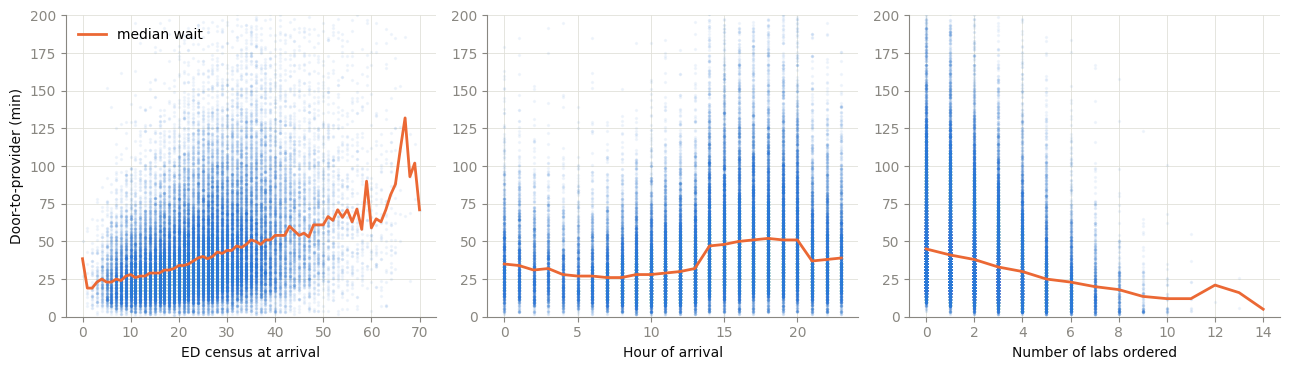

In [2]:
seen = visits[visits["provider_datetime"].notna()].copy()
y = seen["door_to_provider_min"]
print(f"Visits used: {len(seen):,}   wait: median {y.median():.0f} min, mean {y.mean():.1f}, P90 {y.quantile(0.9):.0f}, max {y.max():.0f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, lab in zip(axes, ["ed_census_at_arrival", "arrival_hour", "n_labs"], ["ED census at arrival", "Hour of arrival", "Number of labs ordered"]):
    g = seen.groupby(col)["door_to_provider_min"].median()
    ax.scatter(seen[col], seen["door_to_provider_min"], s=2, alpha=0.05, color=BLUE)
    ax.plot(g.index, g.values, color=ORANGE, linewidth=2, label="median wait")
    ax.set_xlabel(lab); ax.set_ylim(0, 200)
axes[0].set_ylabel("Door-to-provider (min)"); axes[0].legend(frameon=False)
plt.tight_layout(); plt.show()

Three different shapes. Against census, the median wait rises steadily and roughly in a straight line. Against hour, it is flat in the morning and steps up in the afternoon: not a straight line. Against labs, it *falls*: patients with more tests are seen sooner, which seems backwards until you remember that sicker patients get both more tests and faster attention. Keep all three observations; the model will have to answer to them.

## 2. The model as an equation

A linear model with three predictors says that the expected wait is a weighted sum:

$$\text{wait} = \beta_0 + \beta_1 \cdot \text{census} + \beta_2 \cdot \text{hour} + \beta_3 \cdot \text{labs} + \varepsilon$$

- $\beta_0$ is the **intercept**: the expected wait when every predictor is zero (an empty department at midnight with no labs; not a real situation, just where the line starts).
- Each $\beta$ is a **slope**: how much the expected wait changes when that predictor increases by one unit *and the others stay the same*. That last clause is what makes a model different from three separate plots.
- $\varepsilon$ is everything the model does not capture: the residual.

Fitting the model means finding the $\beta$ values that make the residuals as small as possible overall (ordinary least squares). statsmodels does this from a formula that reads almost like the equation.

In [3]:
model_1 = smf.ols("door_to_provider_min ~ ed_census_at_arrival + arrival_hour + n_labs", data=seen).fit()
print(model_1.summary().tables[1])

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               25.2662      0.440     57.456      0.000      24.404      26.128
ed_census_at_arrival     1.0281      0.016     63.144      0.000       0.996       1.060
arrival_hour             0.2141      0.031      6.898      0.000       0.153       0.275
n_labs                  -4.1535      0.082    -50.565      0.000      -4.315      -3.993


## 3. Reading the coefficient table

Each row is one term of the equation. The columns that matter:

- **coef** — the estimated $\beta$. In the units of the response per unit of the predictor: minutes per patient in the department, minutes per hour of the clock, minutes per lab test.
- **std err** — how uncertain that estimate is; with 44,000 visits, small.
- **[0.025, 0.975]** — the 95% confidence interval: the range of values compatible with the data.
- **P>|t|** — the p-value for "the true coefficient is zero". Here every predictor is far below 0.05, which is unsurprising with this much data; the *size* of the effect matters more than the p-value.

Read the numbers in clinical language.

In [4]:
b = model_1.params
print(f"Each additional patient in the department when you arrive adds about {b['ed_census_at_arrival']:.2f} minutes to the expected wait.")
print(f"Each hour later in the day adds about {b['arrival_hour']:.2f} minutes (on average across the day; we will see this is misleading).")
print(f"Each additional lab test is associated with {abs(b['n_labs']):.1f} minutes LESS waiting.")
print()
print("Example: a patient arriving at 15:00 with 30 people in the department and 2 labs ordered.")
example = pd.DataFrame({"ed_census_at_arrival": [30], "arrival_hour": [15], "n_labs": [2]})
print(f"Predicted wait: {model_1.predict(example).iloc[0]:.0f} minutes")

Each additional patient in the department when you arrive adds about 1.03 minutes to the expected wait.
Each hour later in the day adds about 0.21 minutes (on average across the day; we will see this is misleading).
Each additional lab test is associated with 4.2 minutes LESS waiting.

Example: a patient arriving at 15:00 with 30 people in the department and 2 labs ordered.
Predicted wait: 51 minutes


The census effect is the useful one: about a minute per patient, so a department with 40 patients waits roughly 20 minutes longer than one with 20. The labs effect is real in the data but is not what it looks like. It is not that ordering tests speeds things up; it is that `n_labs` is standing in for something the model cannot see (acuity). A coefficient describes an association *given the other variables in the model*, and nothing more. We will return to this in the next session.

## 4. How good is the model?

**R²** is the share of the variation in the response that the model accounts for. The rest is residual: things not in the model plus randomness.

In [5]:
print(f"R² = {model_1.rsquared:.3f}   → the three predictors account for about {model_1.rsquared:.0%} of the variation in waiting time.")
print(f"Residual standard deviation = {np.sqrt(model_1.mse_resid):.1f} minutes  (typical size of a prediction error)")

R² = 0.176   → the three predictors account for about 18% of the variation in waiting time.
Residual standard deviation = 30.7 minutes  (typical size of a prediction error)


Eighteen percent. That is low, and for a first model of an operational outcome it is normal: waiting time depends on acuity, on who happens to be on shift, and on a great deal of chance. A low R² does not make the census coefficient wrong; it says the model is far from a complete account. Whether 18% is disappointing depends on the purpose: it is plenty for understanding how crowding affects waits, and useless for predicting an individual patient's wait.

## 5. Diagnostics: three pictures

A linear model makes assumptions: the relationship is a straight line, the residuals are roughly symmetric and of similar size everywhere, and nothing systematic is left in them. Three plots check these, and each one here fails in an instructive way.

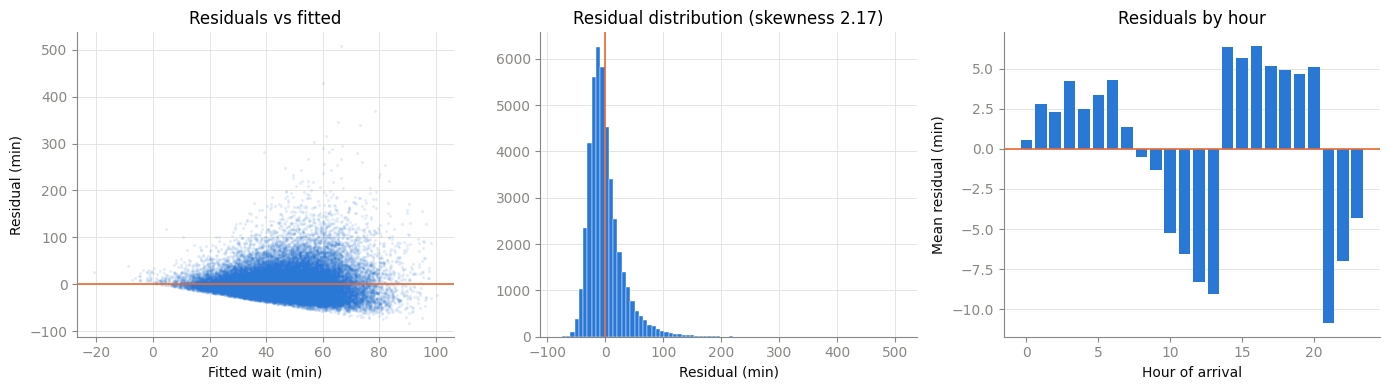

Number of visits with a NEGATIVE predicted wait: 27


In [6]:
resid, fitted = model_1.resid, model_1.fittedvalues
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. residuals against fitted values
axes[0].scatter(fitted, resid, s=2, alpha=0.08, color=BLUE)
axes[0].axhline(0, color=ORANGE, linewidth=1.2)
axes[0].set_xlabel("Fitted wait (min)"); axes[0].set_ylabel("Residual (min)"); axes[0].set_title("Residuals vs fitted")

# 2. distribution of residuals
axes[1].hist(resid, bins=80, color=BLUE, edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color=ORANGE, linewidth=1.2)
axes[1].set_xlabel("Residual (min)"); axes[1].set_title(f"Residual distribution (skewness {stats.skew(resid):.2f})")

# 3. mean residual by hour of arrival
by_hour = resid.groupby(seen["arrival_hour"]).mean()
axes[2].bar(by_hour.index, by_hour.values, color=BLUE, width=0.8)
axes[2].axhline(0, color=ORANGE, linewidth=1.2)
axes[2].set_xlabel("Hour of arrival"); axes[2].set_ylabel("Mean residual (min)"); axes[2].set_title("Residuals by hour"); axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Number of visits with a NEGATIVE predicted wait:", int((fitted < 0).sum()))

**Left: a fan.** The residuals spread out as the fitted wait grows. The model's errors are small when it predicts short waits and large when it predicts long ones, which means the *size* of the noise is proportional to the wait. A model with constant noise cannot represent that.

**Middle: a long right tail.** The residuals are strongly right-skewed (skewness above 2). Waits cannot be negative but can be very long; a symmetric error term is the wrong shape for them, and the model even predicts negative waits for a few visits.

**Right: a pattern by hour.** The mean residual is positive in the afternoon and negative at midday and late evening: the straight-line hour effect underestimates the afternoon and overestimates the rest. There is structure in the hour that a single slope cannot follow.

The first two problems have one classic remedy; the third has another.

## 6. Improvement 1: model the logarithm of the wait

Waiting times, like most durations in healthcare, are **multiplicative**: crowding does not add ten minutes to every wait, it makes every wait a certain percentage longer. A variable that behaves multiplicatively becomes additive on the logarithmic scale, which is exactly what a linear model needs. So model $\log(\text{wait})$ instead of the wait.

Two consequences to accept before fitting. The response must be positive (a 0-minute wait would be $\log 0$; there are none here, but we guard with a floor of one minute). And the coefficients change meaning: a coefficient $\beta$ on the log scale means the wait is multiplied by $e^{\beta}$ per unit of the predictor, which for small $\beta$ is roughly "$\beta \times 100$ percent per unit".

In [7]:
seen["log_wait"] = np.log(seen["door_to_provider_min"].clip(lower=1))
model_2 = smf.ols("log_wait ~ ed_census_at_arrival + arrival_hour + n_labs", data=seen).fit()
print(model_2.summary().tables[1])
print()
print(f"R² on the log scale = {model_2.rsquared:.3f}")

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.2187      0.009    357.030      0.000       3.201       3.236
ed_census_at_arrival     0.0207      0.000     61.906      0.000       0.020       0.021
arrival_hour             0.0069      0.001     10.813      0.000       0.006       0.008
n_labs                  -0.1243      0.002    -73.833      0.000      -0.128      -0.121

R² on the log scale = 0.222


In [8]:
b = model_2.params
print(f"Each additional patient in the department multiplies the expected wait by {np.exp(b['ed_census_at_arrival']):.3f}, i.e. about +{100*(np.exp(b['ed_census_at_arrival'])-1):.1f}% per patient.")
print(f"Ten more patients: ×{np.exp(10*b['ed_census_at_arrival']):.2f}  → a wait of 30 min becomes about {30*np.exp(10*b['ed_census_at_arrival']):.0f} min.")
print(f"Each additional lab test: ×{np.exp(b['n_labs']):.3f}, about {100*(np.exp(b['n_labs'])-1):.0f}%.")

Each additional patient in the department multiplies the expected wait by 1.021, i.e. about +2.1% per patient.
Ten more patients: ×1.23  → a wait of 30 min becomes about 37 min.
Each additional lab test: ×0.883, about -12%.


Percentages are the natural language for waiting times: "twenty more patients in the department and the wait is 50% longer" is how an ED manager thinks. Now the diagnostics again, on the log model.

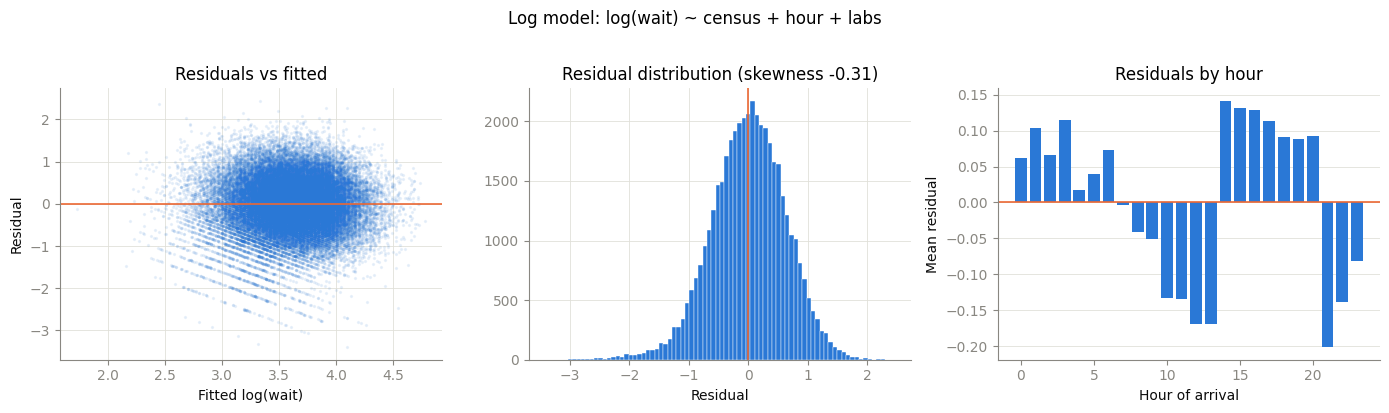

In [9]:
def diagnostics(model, data, title):
    resid, fitted = model.resid, model.fittedvalues
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].scatter(fitted, resid, s=2, alpha=0.08, color=BLUE); axes[0].axhline(0, color=ORANGE, linewidth=1.2)
    axes[0].set_xlabel("Fitted log(wait)"); axes[0].set_ylabel("Residual"); axes[0].set_title("Residuals vs fitted")
    axes[1].hist(resid, bins=80, color=BLUE, edgecolor="white", linewidth=0.3); axes[1].axvline(0, color=ORANGE, linewidth=1.2)
    axes[1].set_xlabel("Residual"); axes[1].set_title(f"Residual distribution (skewness {stats.skew(resid):.2f})")
    by_hour = resid.groupby(data["arrival_hour"]).mean()
    axes[2].bar(by_hour.index, by_hour.values, color=BLUE, width=0.8); axes[2].axhline(0, color=ORANGE, linewidth=1.2)
    axes[2].set_xlabel("Hour of arrival"); axes[2].set_ylabel("Mean residual"); axes[2].set_title("Residuals by hour"); axes[2].grid(axis="x", visible=False)
    fig.suptitle(title, y=1.02); plt.tight_layout(); plt.show()

diagnostics(model_2, seen, "Log model: log(wait) ~ census + hour + labs")

The fan is gone: the residuals have about the same spread at every fitted value. The distribution is close to symmetric (skewness near zero instead of above 2), and no prediction can be negative because $e^{\text{anything}}$ is positive. Two of the three problems disappeared with one transformation, and R² rose as well. The hour pattern is still there, because the log transform changes the *response*, not the *shape* of the hour effect.

## 7. Improvement 2: let the hour effect curve

The hour effect is not a straight line, so give the model a curve. The simplest way is to add a **quadratic term**, $\text{hour}^2$, so that the hour contribution becomes a parabola: $\beta_2 \cdot \text{hour} + \beta_4 \cdot \text{hour}^2$. In a formula, `I(arrival_hour**2)` adds the squared term.

                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.2399      0.013    254.403      0.000       3.215       3.265
ed_census_at_arrival     0.0206      0.000     61.731      0.000       0.020       0.021
arrival_hour             0.0025      0.002      1.261      0.207      -0.001       0.006
I(arrival_hour ** 2)     0.0002   7.72e-05      2.351      0.019    3.02e-05       0.000
n_labs                  -0.1244      0.002    -73.861      0.000      -0.128      -0.121

R²: log model 0.222  →  with quadratic hour 0.222


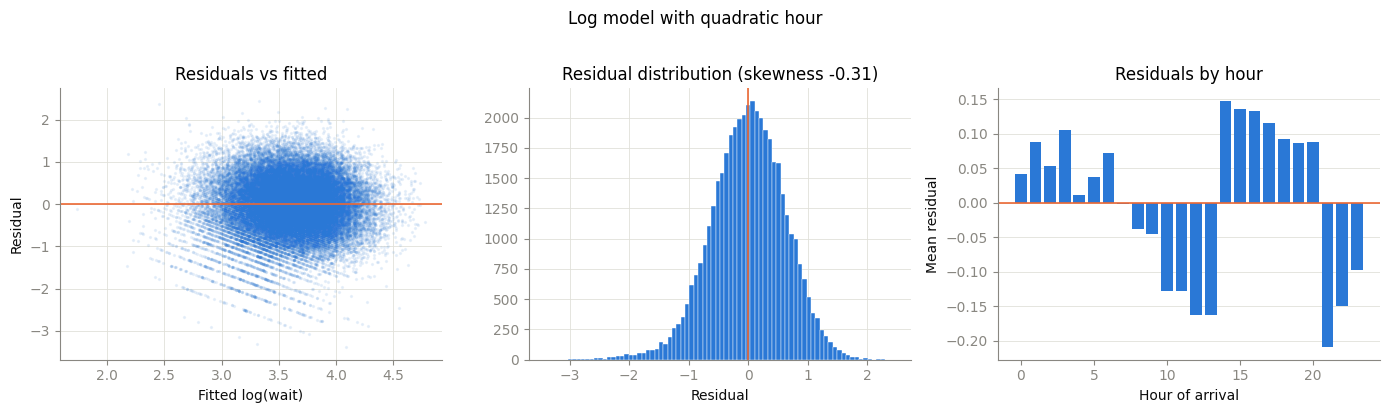

In [10]:
model_3 = smf.ols("log_wait ~ ed_census_at_arrival + arrival_hour + I(arrival_hour**2) + n_labs", data=seen).fit()
print(model_3.summary().tables[1])
print()
print(f"R²: log model {model_2.rsquared:.3f}  →  with quadratic hour {model_3.rsquared:.3f}")
diagnostics(model_3, seen, "Log model with quadratic hour")

The gain is small. The parabola bends the hour effect a little, but the residual-by-hour pattern is almost unchanged: negative around midday, positive from 14:00 to 20:00, negative again late in the evening. A parabola is one smooth hump; what the data shows is a **step** at 14:00 and another down at 21:00, which no smooth curve of low degree can follow. This is worth seeing with your own eyes: adding a curved term is not the same as adding the *right* curved term.

The next session, which brings in categorical variables, is where the remedy lives: an hour *band* (night, morning, afternoon, evening) is a categorical version of the hour that can take a step wherever the data puts one. Adding the quadratic here was not wasted; it showed us the shape of what is missing.

The hour coefficients are now individually hard to interpret (the linear and squared terms only mean something together), so when a curved term is in the model, read its effect from a plot rather than from the table.

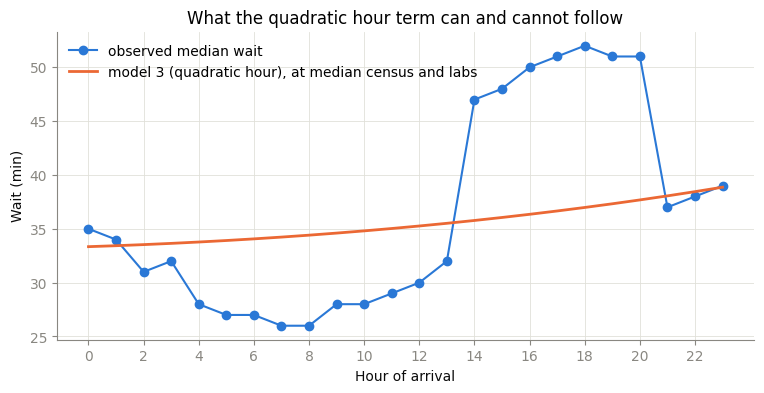

In [11]:
hours = np.arange(0, 24)
curve = pd.DataFrame({"arrival_hour": hours, "ed_census_at_arrival": seen["ed_census_at_arrival"].median(), "n_labs": seen["n_labs"].median()})
pred = np.exp(model_3.predict(curve))
observed = seen.groupby("arrival_hour")["door_to_provider_min"].median()

fig, ax = plt.subplots()
ax.plot(observed.index, observed.values, marker="o", color=BLUE, linewidth=1.5, label="observed median wait")
ax.plot(hours, pred, color=ORANGE, linewidth=2, label="model 3 (quadratic hour), at median census and labs")
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel("Hour of arrival"); ax.set_ylabel("Wait (min)")
ax.set_title("What the quadratic hour term can and cannot follow"); ax.legend(frameon=False); plt.show()

## 8. Where we are, and what the model still cannot see

| Model | Response | Predictors | R² | Diagnostics |
|---|---|---|---|---|
| 1 | wait (min) | census, hour, labs | 0.18 | fan, right skew, hour pattern, negative predictions |
| 2 | log(wait) | census, hour, labs | 0.22 | fan and skew fixed; hour pattern remains |
| 3 | log(wait) | census, hour, hour², labs | 0.22 | as model 2; the parabola cannot follow the step |

Two things are still wrong, and they are the subject of the next session. The hour effect is a step, and a categorical hour band can represent it. And the model has never been told how **sick** each patient was. Acuity is the single biggest driver of how quickly someone is seen, and the strange negative labs coefficient is the shadow it casts: `n_labs` is doing the work of a variable that is not in the model. Once ESI enters, expect the labs coefficient to collapse and R² to double.

Three habits from this session. **Look before you fit.** **Read coefficients in the units of the response**, and on the log scale, as percentages. **Let the residuals tell you what is missing**: the fan asked for a log, the skew asked for a log, and the hour pattern is still asking.